In [1]:
import os
os.chdir('../../..')

print(os.listdir())

['.DS_Store', 'uv.lock', 'config', 'wandb.py', 'pyproject.toml', 'tests', 'utils', 'models', 'README.md', 'results', 'cluster_outputs', '.gitignore', 'figures', '.venv', 'scripts', '.python-version', 'api', 'report', '.git', 'main.py', 'data', 'notebooks', 'src']


# This workbook contains results for the Euclidean baseline clustering

In [2]:
import chemiscope
from ase import Atoms  
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import polars as pl
from collections import Counter
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA
from src.datasets import QM9Dataset
from sklearn.manifold import TSNE

2026-02-22 10:50:48.042 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_morgan_fingerprints()
qm9.add_selfies_onehot()
qm9.add_selfies_transformer()
qm9.add_chemprop()
qm9.add_soap()
qm9.add_acsf()

2026-02-22 10:50:49.328 | INFO     | src.datasets:load:62 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-02-22 10:50:49.376 | INFO     | src.features:compute_morgan_fingerprints:57 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-02-22 10:50:52.534 | INFO     | src.features:compute_selfies_onehot:114 - Computing One-Hot Encodings...
2026-02-22 10:50:53.040 | INFO     | src.features:compute_selfies_transformer:69 - Computing SELFIES-TED Embeddings (ibm-research/materials.selfies-ted)...


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

2026-02-22 10:51:35.463 | INFO     | src.features:compute_chemprop_embeddings:200 - Computing Chemprop embeddings on mps...
2026-02-22 10:51:35.465 | WARNING  | src.features:compute_chemprop_embeddings:208 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-02-22 10:51:37.161 | INFO     | src.features:compute_soap:137 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-02-22 10:51:42.520 | SUCCESS  | src.datasets:add_soap:213 - Added SOAP embeddings.
2026-02-22 10:51:42.520 | INFO     | src.features:compute_acsf:167 - Computing ACSF (rcut=6.0)...
2026-02-22 10:51:46.716 | SUCCESS  | src.datasets:add_acsf:223 - Added ACSF embeddings.


In [4]:
qm9.df

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_onehot,selfies_transformer,chemprop_embedding,soap_embedding,acsf_embedding
str,str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[list[i64]],list[f64],list[f64],list[f64],list[f64]
"""qm9_261""","""[H]N([H])C(=O)C([H])([H])OC([H…","""[H]N([H])C(=O)C([H])([H])OC([H…","""[H][N][Branch1][C][H][C][=Bran…",13,"""Acyclic""",89.094,-0.8819,52.32,6,0,0,3,0.666667,1,2,4,0,6,25,0,0,0,1,1,0,0,0,1,0,3,4.2922,47.529999,-6.704885,0.745592,7.450477,706.14032,2.894203,-8806.729492,-8806.52832,-8806.501953,-8807.601562,24.375,-51.323429,-51.622589,-51.93103,-47.75618,9.29932,1.99725,1.69178,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[-0.140833, 0.120511, … -0.204346]","[0.001527, 0.008335, … 0.00931]","[0.124424, 0.333754, … 0.0]","[3.107281, 1.062942, … 0.0]"
"""qm9_9""","""[H]C([H])([H])C#N""","""[H]C([H])([H])C#N""","""[H][C][Branch1][C][H][Branch1]…",6,"""Acyclic""",41.053,0.52988,23.79,3,0,0,0,0.5,0,1,1,1,3,10,0,0,0,0,0,0,0,0,0,0,1,3.8266,24.450001,-8.881797,1.023148,9.904944,160.722305,1.232295,-3611.444824,-3611.347412,-3611.321533,-3612.097656,10.287,-25.576691,-25.710327,-25.838846,-24.159279,159.035675,9.22327,9.22324,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.209095, -0.062513, … 0.054128]","[0.0, 0.015014, … 0.013914]","[0.115668, 0.305562, … 0.0]","[1.848344, 1.003772, … 0.0]"
"""qm9_879""","""[H]C1=C([H])N(C([H])([H])[H])C…","""[H]c1c(N([H])[H])c([H])n(C([H]…","""[H][C][C][Branch1][=Branch1][N…",15,"""Aromatic""",96.133,0.6073,30.95,7,1,1,2,0.2,1,2,7,0,6,29,0,0,0,1,0,0,0,0,0,0,2,1.8575,64.760002,-4.677637,1.428598,6.106235,773.112976,3.444444,-8291.973633,-8291.77832,-8291.75293,-8292.823242,26.188,-63.148518,-63.530945,-63.890789,-58.881283,6.88602,2.02282,1.58289,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[-0.296135, -0.129948, … -0.269572]","[0.0, 0.003885, … 0.0]","[0.123825, 0.334222, … 0.0]","[3.045083, 0.918204, … 0.0]"
"""qm9_1367""","""[H]C#CC([H])([H])[C@@]([H])(C(…","""[H]C#CC([H])([H])[C@@]([H])(C(…","""[H][C][#C][C][Branch1][C][H][B…",15,"""Acyclic""",96.129,0.8447,17.07,7,0,0,3,0.5,0,1,4,2,6,29,0,0,0,0,0,0,0,0,0,0,1,2.2671,63.740002,-6.857269,-0.753755,6.103514,952.171814,3.31402,-8394.630859,-8394.40625,-8394.379883,-8395.529297,28.608,-63.936234,-64.289497,-64.64933,-59.733788,6.14001,1.3783,1.21574,"[0, 1, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[-0.333777, -0.179636, … -0.32731]","[0.0, 0.0, … 0.002414]","[0.123665, 0.334988, … 0.0]","[3.552306, 0.965528, … 0.0]"
"""qm9_1003""","""[H]C(=O)C1=NC([H])=C([H])O1""","""[H]C(=O)c1nc([H])c([H])o1""","""[H][C][=Branch1][C][=O][C][=N]…",10,"""Aromatic""",97.073,0.4871,43.1,7,1,1,1,0.0,0,3,4,0,5,18,0,0,0,0,0,0,0,0,0,0,3,4.3222,52.75,-7.31442,-2.152421,5.162,660.345093,1.842782,-9778.296875,-9778.149414,-9778.123047,-9779.097656,18.813999,-47.480225,-47.71822,-47.949459,-44.604774,8.58513,2.10593,1.6911,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.374869, 0.223375, … 0.08267]","[0.001941, 0.0, … 0.008592]","[0.070166, 0.193362, … 0.0]","[1.209693, 0.40302, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_1799""","""[H]C1=C([H])[C@@]([H])(C([H])(…","""[H]C1=C([H])[C@@]([H])(C([H])(…","""[H][C][=C][Branch1][C][H][C@@]…",15,"""Aliphatic Ring""",96.129,1.1515,17.07,7,1,0,1,0.5,0,1,6,0,5,31,0,

In [5]:
X_morgan = np.array(qm9.df['morgan_fingerprint'].to_list())
X_onehot = np.array(qm9.df['selfies_onehot'].to_list())
X_onehot = X_onehot.reshape(X_onehot.shape[0], -1)
X_transformer = np.array(qm9.df["selfies_transformer"].to_list())
X_chemprop = np.array(qm9.df["chemprop_embedding"].to_list())
X_soap = np.array(qm9.df["soap_embedding"].to_list())
X_acsf = np.array(qm9.df["acsf_embedding"].to_list())

In [24]:

model = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_onehot = model.fit_predict(X_onehot)
labels_morgan = model.fit_predict(X_morgan)
labels_transformer = model.fit_predict(X_transformer)
labels_chemprop = model.fit_predict(X_chemprop)
labels_soap = model.fit_predict(X_soap)
labels_acsf = model.fit_predict(X_acsf)

qm9.df = qm9.df.with_columns(
    onehot_labels=labels_onehot,
    morgan_labels=labels_morgan,
    transformer_labels = labels_transformer,
    chemprop_labels = labels_chemprop,
    soap_labels = labels_soap,
    acsf_labels = labels_acsf
)

df = qm9.df.drop([
    "morgan_fingerprint", "selfies_onehot", "selfies_transformer", 
    "chemprop_embedding", "soap_embedding", "acsf_embedding"
])

df.write_csv('report/qm9/euclidean_baseline/csv/qm9_clusterlabels.csv')

In [25]:

def get_structures():
    # Extract both the IDs and the SMILES strings
    mol_ids = qm9.df["mol_id"].to_list()
    smiles_list = qm9.df["canonical_smiles"].to_list()
    
    structures = []  
    valid_indices = [] # We need to track this (see warning below)
    
    for i, (mol_id, s) in enumerate(zip(mol_ids, smiles_list)):
        if s is None:
            print(f"Skipping {mol_id}: SMILES is missing.")
            continue
            
        mol = Chem.MolFromSmiles(s)
        if mol is None: 
            print(f"Skipping {mol_id}: RDKit could not parse SMILES.")
            continue
            
        mol = Chem.AddHs(mol)

        res = AllChem.EmbedMolecule(mol, AllChem.ETKDG())
        if res != 0: 
            print(f"Skipping {mol_id}: Failed to generate 3D conformer.")
            continue

        conf = mol.GetConformer()
        positions = conf.GetPositions()
        numbers = [a.GetAtomicNum() for a in mol.GetAtoms()]
        
        atoms = Atoms(numbers=numbers, positions=positions)
        structures.append(atoms)
        valid_indices.append(i)
        
    return structures, valid_indices


def write_chemiscope(X):
    structures, valid_indicies = get_structures()

    X = X[valid_indicies]
    model = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = model.fit_predict(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    properties = {
        "PCA 1": X_pca[:, 0],
        "PCA 2": X_pca[:, 1],
        "Cluster": labels,
    }

    output_path = "report/qm9/euclidean_baseline/csv/visualization.json.gz"

    chemiscope.write_input(
        output_path,
        structures=structures,
        properties=properties,
    )
    return output_path

output_path = write_chemiscope(X_morgan)

Skipping qm9_686: Failed to generate 3D conformer.


- Oxygen: Red
- Nitrogen: Blue
- Hydrogen: White
- Sulfur: Yellow
- Carbon : Grey / Black

In [10]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'visualization'}, structures=[{'size': 13, 'data': 'structure-0'}, {'size': 6,…

Processing: One-hot...
Processing: Morgan...
Processing: Transformer...
Processing: ChemProp...
Processing: SOAP...
Processing: ACSF...
Saved to report/qm9/appendix/cluster_metrics.png


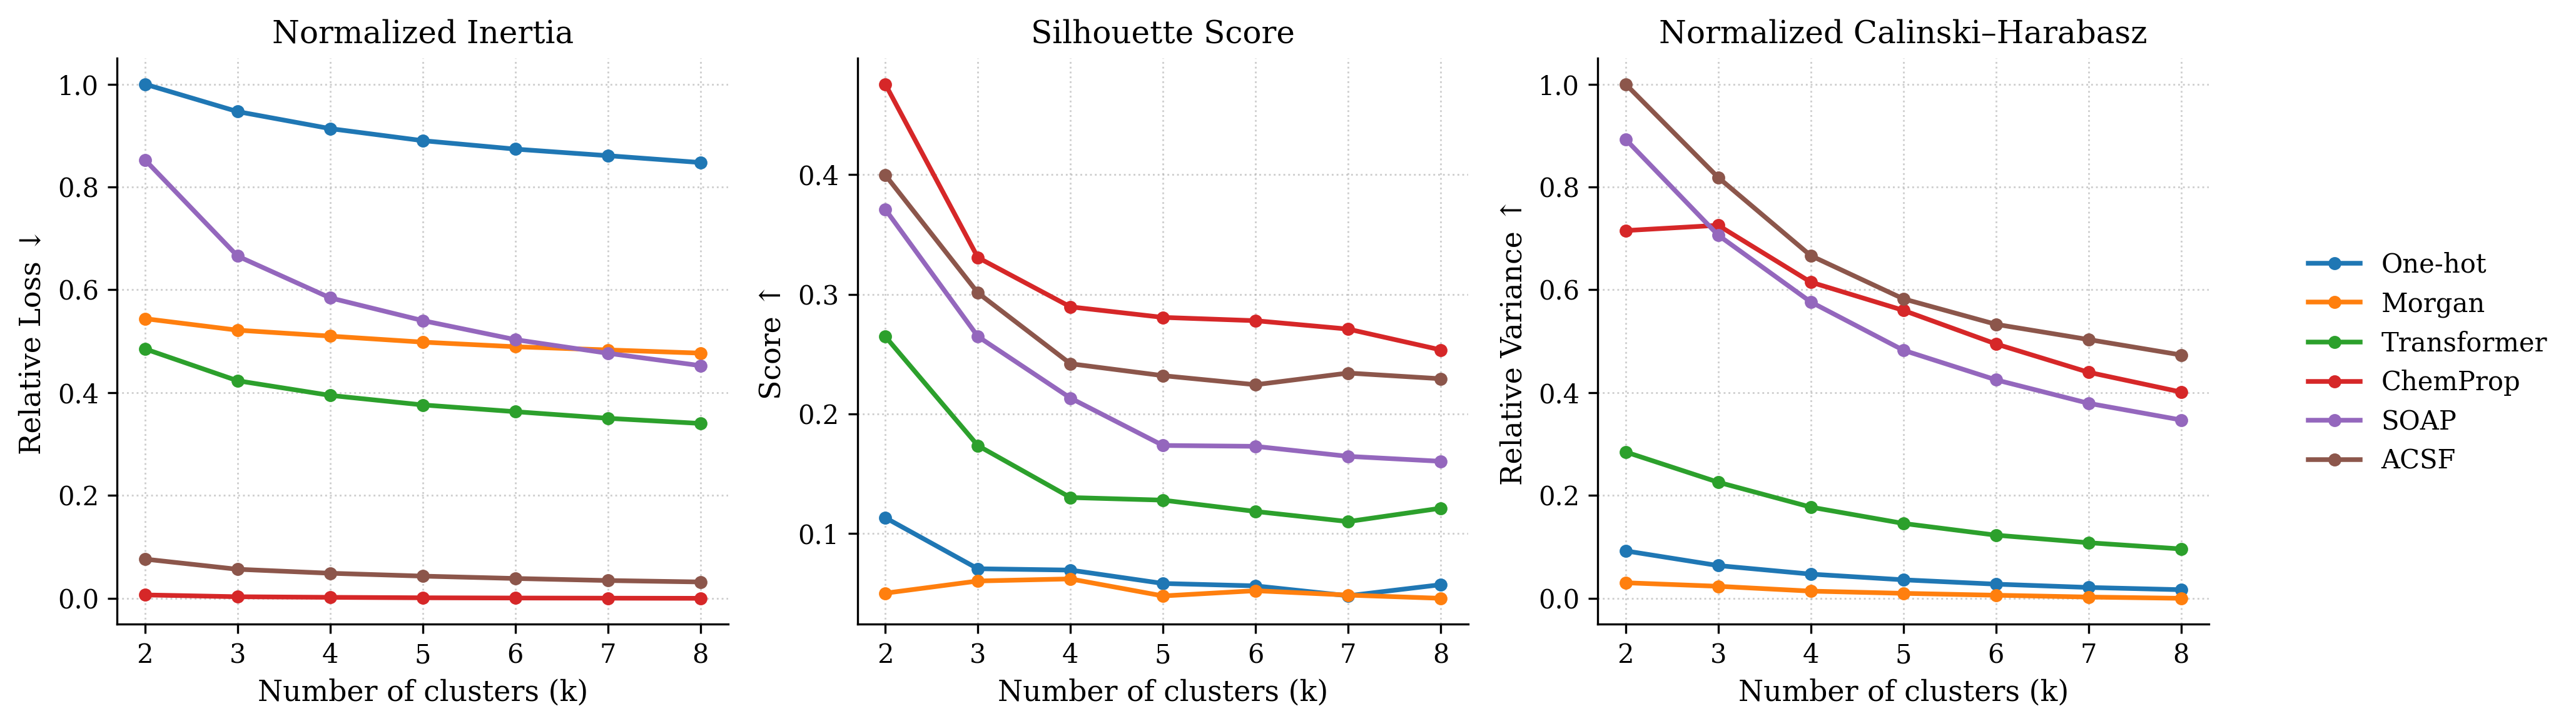

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import MinMaxScaler


def plot_combined_clustering_metrics(
    embeddings_dict,
    max_k=8,
    save_path=None,
):
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

    colors = plt.get_cmap("tab10").colors

    k_values = list(range(2, max_k + 1))
    results = {name: {'inertia': [], 'silhouette': [], 'ch': []}
               for name in embeddings_dict}

    for name, X in embeddings_dict.items():
        print(f"Processing: {name}...")

        for k in k_values:
            model = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = model.fit_predict(X)

            results[name]['inertia'].append(model.inertia_)
            results[name]['silhouette'].append(silhouette_score(X, labels))
            results[name]['ch'].append(calinski_harabasz_score(X, labels))

    scaler = MinMaxScaler()

    for metric in ["inertia", "ch"]:
        all_vals = np.concatenate([
            np.array(results[name][metric]).reshape(-1, 1)
            for name in embeddings_dict
        ])
        scaler.fit(all_vals)

        for name in embeddings_dict:
            vals = np.array(results[name][metric]).reshape(-1, 1)
            results[name][metric] = scaler.transform(vals).flatten()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=300)

    metrics = ["inertia", "silhouette", "ch"]
    titles = [
        "Normalized Inertia",
        "Silhouette Score",
        "Normalized Calinski–Harabasz"
    ]
    ylabels = [
        "Relative Loss ↓",
        "Score ↑",
        "Relative Variance ↑"
    ]

    for i, metric in enumerate(metrics):
        ax = axes[i]

        for idx, name in enumerate(embeddings_dict):
            ax.plot(
                k_values,
                results[name][metric],
                marker="o",
                markersize=4,
                linewidth=1.8,
                label=name,
                color=colors[idx % len(colors)],
            )

        ax.set_title(titles[i])
        ax.set_xlabel("Number of clusters (k)")
        ax.set_ylabel(ylabels[i])
        ax.set_xticks(k_values)
        ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

    # Right-side legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),  # outside right, vertically centered
        frameon=False,
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Saved to {save_path}")

    plt.show()

embeddings = {
    "One-hot": X_onehot,
    "Morgan": X_morgan,
    "Transformer": X_transformer,
    "ChemProp": X_chemprop,
    "SOAP": X_soap,
    "ACSF": X_acsf,
}

plot_combined_clustering_metrics(embeddings, save_path="report/qm9/appendix/cluster_metrics.png")

# Cluster composition analysis

In [13]:
#print(df["morgan_labels"].value_counts(), df["onehot_labels"].value_counts(), df["transformer_labels"].value_counts(), df["chemprop_labels"].value_counts(), df["soap_labels"].value_counts(), df["acsf_labels"].value_counts())

In [27]:
import pandas as pd

def generate_cluster_report(df, label_col, output_csv="cluster_profile.csv"):
    print(f"Generating report for: '{label_col}'...")
    
    # 1. Pre-check: Calculate shape_class if missing but A, B, C are present
    if "shape_class" not in df.columns and "A" in df.columns:
        kappa = (2 * pl.col("B") - pl.col("A") - pl.col("C")) / (pl.col("A") - pl.col("C") + 1e-6)
        df = df.with_columns([
            pl.when((pl.col("A") - pl.col("C")) / pl.col("A") < 0.05).then(pl.lit("Spherical"))
            .when(kappa < -0.8).then(pl.lit("Prolate (Rod)"))
            .when(kappa > 0.8).then(pl.lit("Oblate (Disk)"))
            .otherwise(pl.lit("Asymmetric Top")).alias("shape_class")
        ])

    properties_to_analyze = [
        "gap", "mu", "alpha", "homo", "lumo", "cv", "mol_weight", "tpsa",
        "raw_token_count", "main_chain_length", "num_sp_carbons", "branching_index"
    ]
    
    valid_props = [p for p in properties_to_analyze if p in df.columns]
    
    summary = (
        df.group_by(label_col)
        .agg(
            [pl.col(p).mean().alias(f"avg_{p}") for p in valid_props] +
            [pl.len().alias("molecule_count")]
        )
        .sort(label_col)
        .to_pandas()
        .set_index(label_col)
    )
    
    categorical_dfs = []
    for cat_col in ["structure_class", "shape_class"]:
        if cat_col in df.columns:
            pivot = (
                df.group_by([label_col, cat_col])
                .len()
                .pivot(on=cat_col, index=label_col, values="len")
                .fill_null(0)
                .to_pandas()
                .set_index(label_col)
            )
            pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
            pct.columns = [f"pct_{cat_col}_{c}" for c in pct.columns]
            categorical_dfs.append(pct)

    fr_cols = [c for c in df.columns if c.startswith("fr_")]
    fr_profile = df.group_by(label_col).agg([pl.col(c).mean() for c in fr_cols]).sort(label_col).to_pandas().set_index(label_col)
    fr_profile.columns = [f"avg_{c}" for c in fr_profile.columns]

    # Atom Composition
    print("Calculating atom compositions...")
    def get_atom_counts(smiles):
        mol = Chem.MolFromSmiles(smiles)
        return dict(Counter([a.GetSymbol() for a in mol.GetAtoms()])) if mol else {}

    atom_counts = pl.from_dicts(df["smiles"].map_elements(get_atom_counts, return_dtype=pl.Object).to_list()).fill_null(0)
    analysis_df = pl.concat([df.select(label_col), atom_counts], how="horizontal")
    cluster_sums = analysis_df.group_by(label_col).sum().sort(label_col)
    atom_cols = [c for c in cluster_sums.columns if c != label_col]
    total_atoms = cluster_sums.select(atom_cols).sum_horizontal()
    composition = cluster_sums.select([pl.col(label_col)] + [(pl.col(c) / total_atoms * 100).alias(f"pct_atom_{c}") for c in atom_cols]).to_pandas().set_index(label_col)

    final_report = pd.concat([summary] + categorical_dfs + [fr_profile, composition], axis=1)
    final_report = final_report.fillna(0).round(3)
    final_report.to_csv(output_csv)
    print(f"Saved: {output_csv}")
    return final_report

embedding = "chemprop"
generate_cluster_report(df, label_col=embedding+'_labels', output_csv=f"report/qm9/euclidean_baseline/csv/{embedding}_profile.csv")

Generating report for: 'chemprop_labels'...
Calculating atom compositions...
Saved: report/qm9/euclidean_baseline/csv/chemprop_profile.csv


,avg_gap,avg_mu,avg_alpha,avg_homo,avg_lumo,avg_cv,avg_mol_weight,avg_tpsa,avg_raw_token_count,avg_main_chain_length,...,avg_fr_ester,avg_fr_ketone,avg_fr_ether,avg_fr_nitro,avg_fr_halogen,pct_atom_N,pct_atom_C,pct_atom_O,pct_atom_F,pct_atom_H
chemprop_labels,,,,,,,,,,,,,,,,,,,,,
0,6.277,2.516,52.407,-6.114,0.163,20.697,91.509,41.841,20.386,5.191,...,0.000,0.003,0.028,0.0,2.693,27.657,59.250,13.093,0.000,0.0
1,8.117,1.884,58.553,-6.778,1.339,25.006,93.180,22.786,32.758,5.276,...,0.019,0.070,0.509,0.0,1.455,5.877,77.889,16.234,0.000,0.0
2,7.114,2.752,55.488,-7.033,0.081,25.375,92.711,36.273,27.422,5.623,...,0.077,0.172,0.311,0.0,2.139,11.301,66.805,21.247,0.246,0.4


In [ ]:
os.listdir()

['Bachelor', '.DS_Store', 'Kandidat', 'Notes', 'data', 'Andet']